# BART: Bayesian Additive Regression Trees

**Authors: Mathieu LONGATTE, Louison Mocq**

**Based on:** Chipman, George & McCulloch (2010) — *BART: Bayesian Additive Regression Trees*, Annals of Applied Statistics.

In this notebook, we illustrate its ability to quantify epistemic uncertainty,
to perform variable selection, and to handle high-dimensional data. We complement the experimental study of by considering
additional datasets and more recent baselines, such as XGBoost and LightGBM, which were not yet
available when BART was originally introduced.

## Setup 


In [1]:
pip install -r requirements.txt

  Cloning https://github.com/JakeColtman/bartpy.git to /private/var/folders/rj/jncxshgs6tjb572dxm8jzvwc0000gn/T/pip-req-build-q7a8savw
  Running command git clone --filter=blob:none --quiet https://github.com/JakeColtman/bartpy.git /private/var/folders/rj/jncxshgs6tjb572dxm8jzvwc0000gn/T/pip-req-build-q7a8savw
  Resolved https://github.com/JakeColtman/bartpy.git to commit 09e409e91dd1b9d44784c788c2d731dafb181eb0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
from scipy.stats import norm
import random as rd

from sklearn.datasets import fetch_california_housing, load_diabetes, make_friedman1, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor,
                               GradientBoostingClassifier, RandomForestClassifier)
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

from bartpy.sklearnmodel import SklearnModel as BARTpy

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [3]:
def set_seed(seed):
    np.random.seed(seed)
    rd.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
set_seed(42)

---
## BART Implementation: bartpy

This notebook uses **`bartpy`** (github.com/JakeColtman/bartpy).

In [4]:
def bartpy_fit(X, y, n_trees=50, n_samples=200, n_burn=200, n_jobs=1, **kwargs):
    """Wrapper for bartpy.SklearnModel fit (store_in_sample_predictions=True required)."""
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    model = BARTpy(
        n_trees=n_trees, n_samples=n_samples, n_burn=n_burn,
        n_jobs=n_jobs, store_in_sample_predictions=True, **kwargs
    )
    model.fit(X, np.array(y, dtype=float))
    return model


def bartpy_predict(model, X=None):
    """Posterior mean prediction (in-sample if X=None, OOS otherwise)."""
    if X is None:
        return model.predict()
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    return model.predict(X)


def bartpy_credible_interval(model, alpha=0.90):
    """In-sample credible intervals from _prediction_samples (normalized space → unnormalized)."""
    raw = model._prediction_samples
    if hasattr(raw, '__len__') and len(raw) == 0:
        raise ValueError("_prediction_samples is empty: check store_in_sample_predictions=True")
    unnorm = np.array([model.data.y.unnormalize_y(s) for s in raw])
    lo, hi = (1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100
    return unnorm.mean(axis=0), np.percentile(unnorm, lo, axis=0), np.percentile(unnorm, hi, axis=0)


def bartpy_sigma_trace(model):
    """Sigma trace — current_value is a method in bartpy (not a property)."""
    return np.array([s.sigma.current_value() for s in model._model_samples])


def _inspect_node_feature(node):
    """
    Extract the feature index from a bartpy node.
    Tries all known variants of the internal API.
    Returns an int or None if the node is a leaf / unknown structure.
    """
    # Variant 1: node.split_conditions (list of SplitCondition)
    try:
        for cond in node.split_conditions:
            v = cond.splitting_variable
            if v is not None:
                return int(v)
    except (AttributeError, TypeError):
        pass

    # Variant 2: node.split.splitting_variable (direct Split object)
    try:
        v = node.split.splitting_variable
        if v is not None:
            return int(v)
    except (AttributeError, TypeError):
        pass

    # Variant 3: node.splitting_variable directly
    try:
        v = node.splitting_variable
        if v is not None:
            return int(v)
    except (AttributeError, TypeError):
        pass

    # Variant 4: node.data.X has a mask -> infer from parent tree
    # (too complex, skipping)
    return None


def bartpy_var_usage(model, p):
    """
    Split frequency per variable (dynamic node inspection).
    Uses _inspect_node_feature which tries several API variants.
    """
    counts = np.zeros(p, dtype=float)
    n_found = 0

    for m_sample in model._model_samples:
        for tree in m_sample.trees:
            try:
                nodes = list(tree.nodes)
            except (AttributeError, TypeError):
                try:
                    nodes = [tree]  # fallback
                except Exception:
                    continue
            for node in nodes:
                feat = _inspect_node_feature(node)
                if feat is not None and 0 <= feat < p:
                    counts[feat] += 1
                    n_found += 1

    if n_found == 0:
        # Fallback: use prediction_samples to approximate importance
        # via prediction variance when permuting each feature
        print("  bartpy_var_usage: no splits found via internal API.")
        print("   Falling back to permutation importance proxy.")
        return _var_importance_permutation(model, p)

    total = counts.sum()
    return counts / total


def _var_importance_permutation(model, p):
    """
    Permutation importance proxy on training data.
    Used only if internal splits API is inaccessible.
    """
    X_train = model.data.X.original_X_by_col  # (n, p), normalisé
    base_pred = model.predict()
    importances = np.zeros(p)
    for j in range(p):
        X_perm = X_train.copy()
        X_perm[:, j] = np.random.permutation(X_perm[:, j])
        perm_pred = sum(tree.predict(X_perm) for tree in model.model_samples[-1].trees
                        if hasattr(tree, 'predict'))
        importances[j] = np.var(base_pred - perm_pred)
    total = importances.sum()
    return importances / total if total > 0 else importances


def debug_bartpy_node(model, n_samples_check=3, n_nodes_check=5):
    """
    Prints bartpy node structure to diagnose the API.
    Call after first fit if bartpy_var_usage returns zeros.
    """
    print("=== Debug bartpy node structure ===")
    for i, m_sample in enumerate(model._model_samples[:n_samples_check]):
        for tree in list(m_sample.trees)[:2]:
            for node in list(tree.nodes)[:n_nodes_check]:
                attrs = [a for a in dir(node) if not a.startswith('__')]
                print(f"  Sample {i}, node attrs: {attrs[:15]}")
                break
            break
        break

In [5]:
def bartpy_partial_dependence(
    model,
    X_reference,
    feature_index,
    grid=None,
    num_grid_points=50,
    use_quantiles=True,
    return_std=False,
):
    X_reference = np.asarray(X_reference)
    if X_reference.ndim != 2:
        raise ValueError("X_reference must be a 2D array")

    n_samples, n_features = X_reference.shape
    if not (0 <= feature_index < n_features):
        raise IndexError("feature_index out of bounds")

    xj = X_reference[:, feature_index]

    if grid is None:
        if use_quantiles:
            probs = np.linspace(0.01, 0.99, num_grid_points)
            grid = np.quantile(xj, probs)
            grid = np.unique(grid)
        else:
            grid = np.linspace(np.min(xj), np.max(xj), num_grid_points)
    else:
        grid = np.asarray(grid)

    pd_values = []
    pd_stds = []

    for value in grid:
        X_mod = X_reference.copy()
        X_mod[:, feature_index] = value

        preds = bartpy_predict(model, X_mod)
        preds = np.asarray(preds)

        pd_values.append(np.mean(preds))
        if return_std:
            pd_stds.append(np.std(preds))

    pd_values = np.asarray(pd_values)

    if return_std:
        return grid, pd_values, np.asarray(pd_stds)

    return grid, pd_values

In [6]:
def bartpy_credible_interval_oos(model, X_new, alpha=0.90):
    """
    Out-of-sample credible intervals from _model_samples
    (normalized space -> unnormalized space).
    """

    raw = getattr(model, "_model_samples", None)
    if raw is None or len(raw) == 0:
        raise ValueError("_model_samples is empty: fit the model first")

    pred_samples_norm = np.array([
        m._out_of_sample_predict(X_new) for m in raw
    ])

    pred_samples = np.array([
        model.data.y.unnormalize_y(s) for s in pred_samples_norm
    ])

    lo, hi = (1 - alpha) / 2 * 100, (1 + alpha) / 2 * 100

    return (
        pred_samples.mean(axis=0),
        np.percentile(pred_samples, lo, axis=0),
        np.percentile(pred_samples, hi, axis=0),
    )

---
## Uncertainty Quantification: California Housing

Unlike point-estimate methods (Random Forest, Gradient Boosting), BART delivers full **credible intervals** for every prediction. This is BART's most distinctive feature.

In [7]:
def evenly_spaced_indices(n, k=500):
    if k >= n:
        return np.arange(n)
    return np.unique(np.linspace(0, n - 1, k, dtype=int))

In [8]:
def experiment_housing(n_data=100,n_trees=200, n_samples=1000, n_burn=1000,seed=42):
    set_seed(seed)
    cal = fetch_california_housing()
    X_cal, y_cal = cal.data, cal.target
    feature_names = list(cal.feature_names)

    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_cal, y_cal, test_size=0.2, random_state=42
    )
    idx = np.random.choice(len(y_train_b), n_data, replace=False)
    X_train_b, y_train_b = X_train_b[idx], y_train_b[idx]

    print(f"Train: {X_train_b.shape}, Test: {X_test_b.shape}")
    print("Fitting BART (bartpy)...")

    bart_cal = bartpy_fit(X_train_b, y_train_b, n_trees=200, n_samples=1000, n_burn=1000)

    print("Fit complete.")

    f_mean_is, f_lower_is, f_upper_is = bartpy_credible_interval(bart_cal, alpha=0.95)
    f_mean_os ,f_lower_os, f_upper_os = bartpy_credible_interval_oos(bart_cal,X_test_b, alpha=0.95)

    ci_width = f_upper_os - f_lower_os
    mean_ci_width = np.mean(ci_width)

    train_rmse  = np.sqrt(mean_squared_error(y_train_b, f_mean_is))

    oos_pred    = bartpy_predict(bart_cal, X_test_b)
    test_rmse   = np.sqrt(mean_squared_error(y_test_b, oos_pred))

    sigma_trace = bartpy_sigma_trace(bart_cal)
    sigma_mean  = sigma_trace.mean()

    print(f"In-sample   RMSE = {train_rmse:.4f}")
    print(f"Out-of-sample RMSE = {test_rmse:.4f}")
    print(f"Mean CI width (OOS) (95%) = {mean_ci_width:.4f}")
    print(f"Posterior mean sigma = {sigma_mean:.4f}")
    print(f"CI width / sigma = {mean_ci_width / sigma_mean:.2f}")

    print(f"In-sample   RMSE = {train_rmse:.4f}")
    print(f"Out-of-sample RMSE = {test_rmse:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"BART (bartpy) — California Housing\nMean σ = {sigma_mean:.3f} | Mean CI width = {mean_ci_width:.3f} | CI/4σ = {mean_ci_width / (4* sigma_mean):.2f}",
        fontsize=13,
        fontweight='bold'
    )

    #in-sample CI
    ax = axes[0]
    sort_idx = np.argsort(y_train_b)
    ax.fill_between(range(len(sort_idx)), f_lower_is[sort_idx], f_upper_is[sort_idx],
                    alpha=0.35, color='royalblue', label='95% CI')
    ax.plot(f_mean_is[sort_idx], color='royalblue', lw=1.5, label='BART mean')
    ax.scatter(range(len(sort_idx)), y_train_b[sort_idx],
            s=12, color='tomato', alpha=0.7, label='True y', zorder=5)
    ax.set_title(f'In-sample (TRAIN)\nRMSE={train_rmse:.3f}')
    ax.set_xlabel("Observations (sorted by y)")
    ax.set_ylabel("Median house value ($100k)")
    ax.legend(fontsize=8)

    #sigma trace
    ax = axes[1]
    ax.plot(sigma_trace, color='darkgreen', lw=1, alpha=0.8)
    ax.axhline(sigma_trace.mean(), color='red', linestyle='--',
            label=f'Mean Sigma={sigma_trace.mean():.4f}')
    ax.set_xlabel("MCMC sample")
    ax.set_ylabel("Sigma")
    ax.set_title("Posterior Sigma trace\n(MCMC convergence)")
    ax.legend()

    # Out-of-sample mean + CI
    ax = axes[2]
    sort_idx = np.argsort(y_test_b)
    keep = evenly_spaced_indices(len(sort_idx), k=500)
    idx = sort_idx[keep]

    x_plot = np.arange(len(idx))
    ax.fill_between(x_plot, f_lower_os[idx], f_upper_os[idx],
                    alpha=0.35, color='royalblue', label='95% CI')
    ax.plot(x_plot, f_mean_os[idx], color='royalblue', lw=1.5, label='BART mean')
    ax.scatter(x_plot, y_test_b[idx],
            s=12, color='tomato', alpha=0.7, label='True y', zorder=5)
    ax.set_title(f'Out-of-sample (TEST)\nRMSE={test_rmse:.3f}')
    ax.set_xlabel("500 observations evenly sampled\n(sorted by y)")
    ax.set_ylabel("Median house value ($100k)")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


Train: (100, 8), Test: (4128, 8)
Fitting BART (bartpy)...
Starting burn


100%|██████████| 1000/1000 [00:14<00:00, 67.05it/s]


Starting sampling


100%|██████████| 1000/1000 [00:14<00:00, 70.28it/s]


Starting burn


...

Starting burn


100%|██████████| 1000/1000 [00:15<00:00, 63.92it/s]


Starting sampling


100%|██████████| 1000/1000 [00:15<00:00, 65.74it/s]


Fit complete.
In-sample   RMSE = 0.7388
Out-of-sample RMSE = 0.7239
Mean CI width (OOS) (95%) = 0.4156
Posterior mean sigma = 0.1645
CI width / sigma = 2.53
In-sample   RMSE = 0.7388
Out-of-sample RMSE = 0.7239


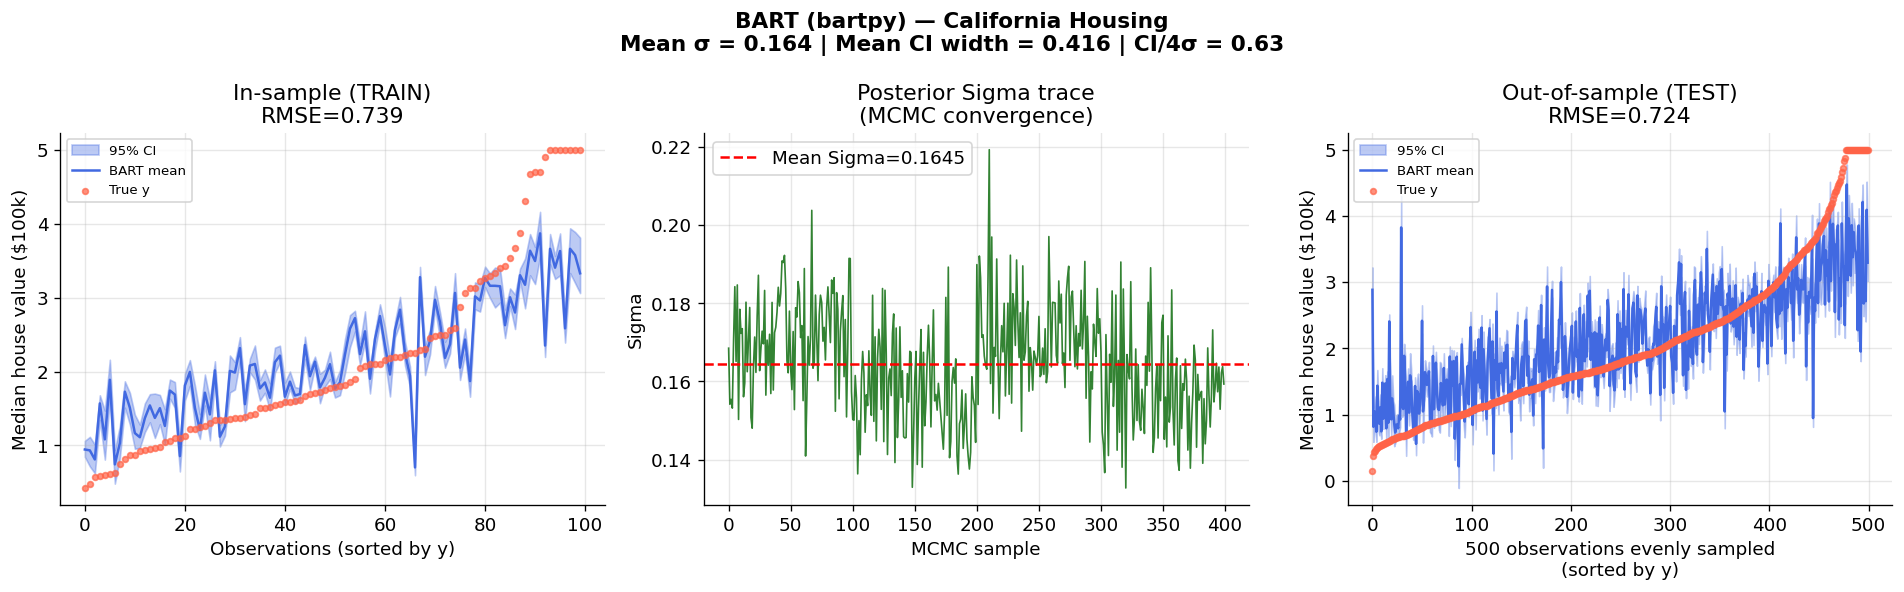

In [9]:
experiment_housing(n_data=100)

Train: (1000, 8), Test: (4128, 8)
Fitting BART (bartpy)...
Starting burn


100%|██████████| 1000/1000 [00:17<00:00, 56.76it/s]


Starting sampling


100%|██████████| 1000/1000 [00:18<00:00, 54.10it/s]


Starting burn


...

Starting burn


100%|██████████| 1000/1000 [00:17<00:00, 56.57it/s]


Starting sampling


100%|██████████| 1000/1000 [00:21<00:00, 47.47it/s]


Fit complete.
In-sample   RMSE = 0.6012
Out-of-sample RMSE = 0.6307
Mean CI width (OOS) (95%) = 0.3480
Posterior mean sigma = 0.1347
CI width / sigma = 2.58
In-sample   RMSE = 0.6012
Out-of-sample RMSE = 0.6307


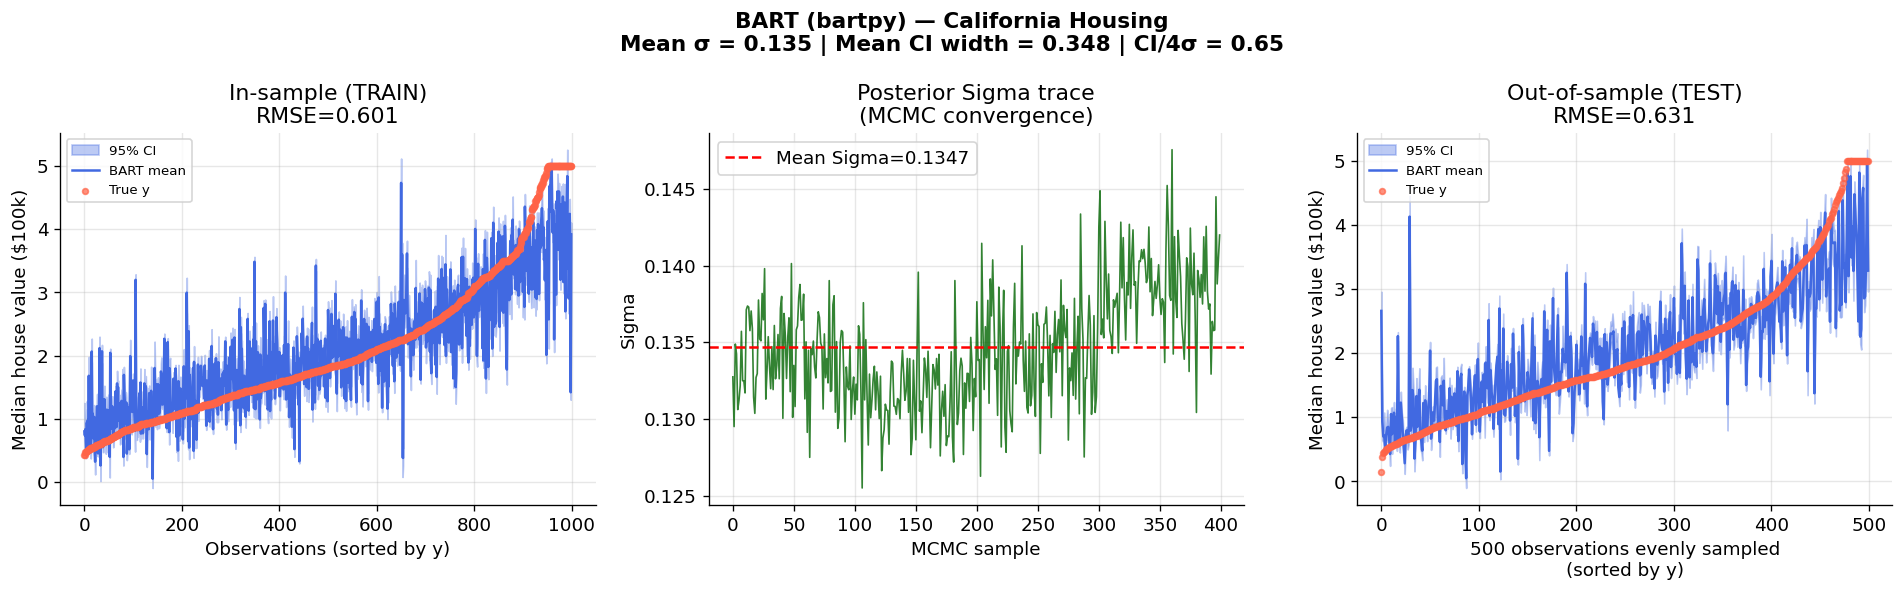

In [10]:
experiment_housing(n_data=1000)

Train: (10000, 8), Test: (4128, 8)
Fitting BART (bartpy)...
Starting burn


100%|██████████| 1000/1000 [00:44<00:00, 22.31it/s]


Starting sampling


100%|██████████| 1000/1000 [00:43<00:00, 23.20it/s]


Starting burn


...

Starting burn


100%|██████████| 1000/1000 [00:42<00:00, 23.37it/s]


Starting sampling


100%|██████████| 1000/1000 [00:41<00:00, 23.99it/s]


Fit complete.
In-sample   RMSE = 0.5319
Out-of-sample RMSE = 0.5610
Mean CI width (OOS) (95%) = 0.3926
Posterior mean sigma = 0.1147
CI width / sigma = 3.42
In-sample   RMSE = 0.5319
Out-of-sample RMSE = 0.5610


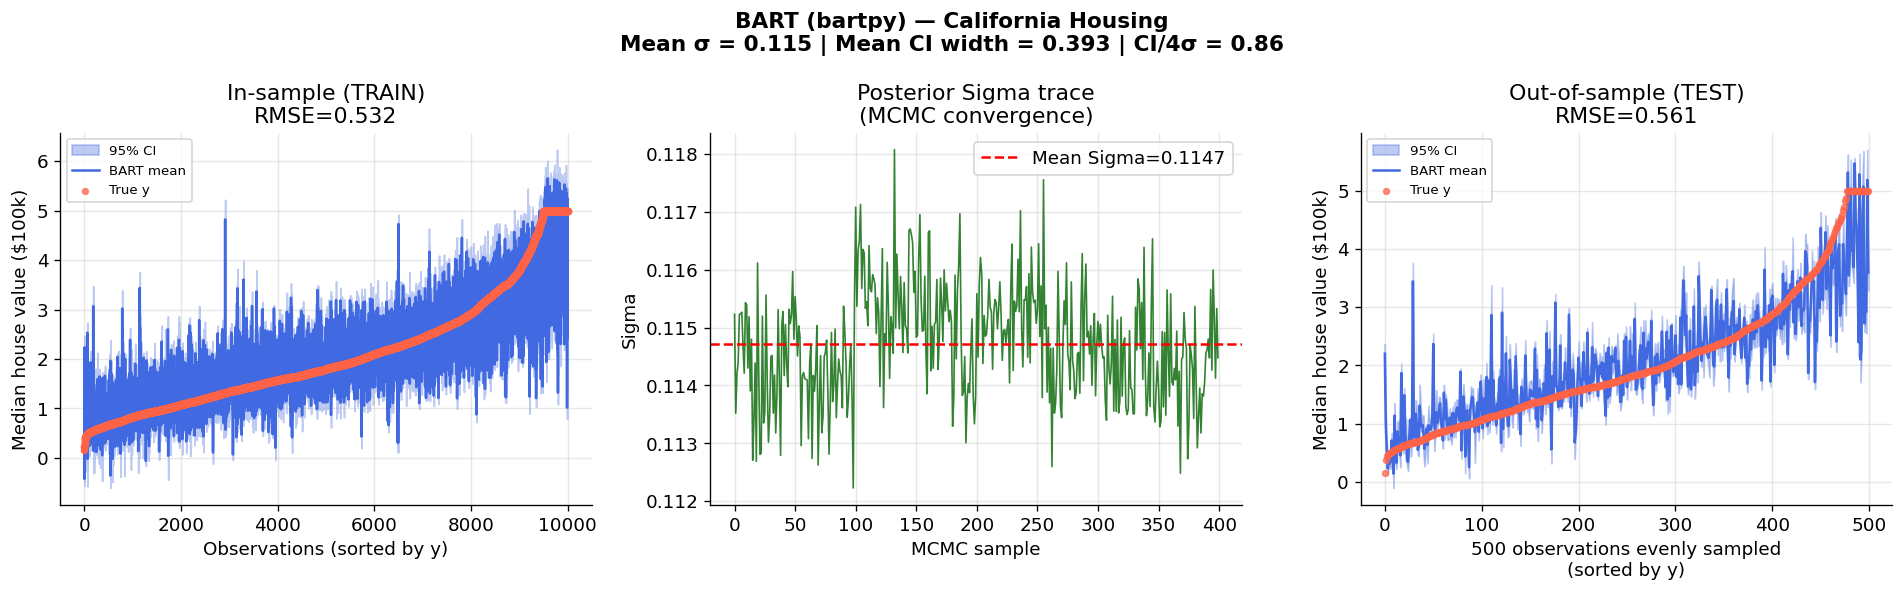

In [11]:
experiment_housing(n_data=10000)

---
## Feature Selection: Diabetes Dataset

Diabetes: 442 samples, 10 features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Fitting bartpy for m=5 over 5 seeds...
Starting burn


100%|██████████| 150/150 [00:00<00:00, 2334.74it/s]


Starting sampling


100%|██████████| 200/200 [00:00<00:00, 2338.14it/s]


Starting burn


...

100%|██████████| 200/200 [00:00<00:00, 248.25it/s]


Starting burn


100%|██████████| 150/150 [00:00<00:00, 246.76it/s]


Starting sampling


100%|██████████| 200/200 [00:00<00:00, 254.02it/s]


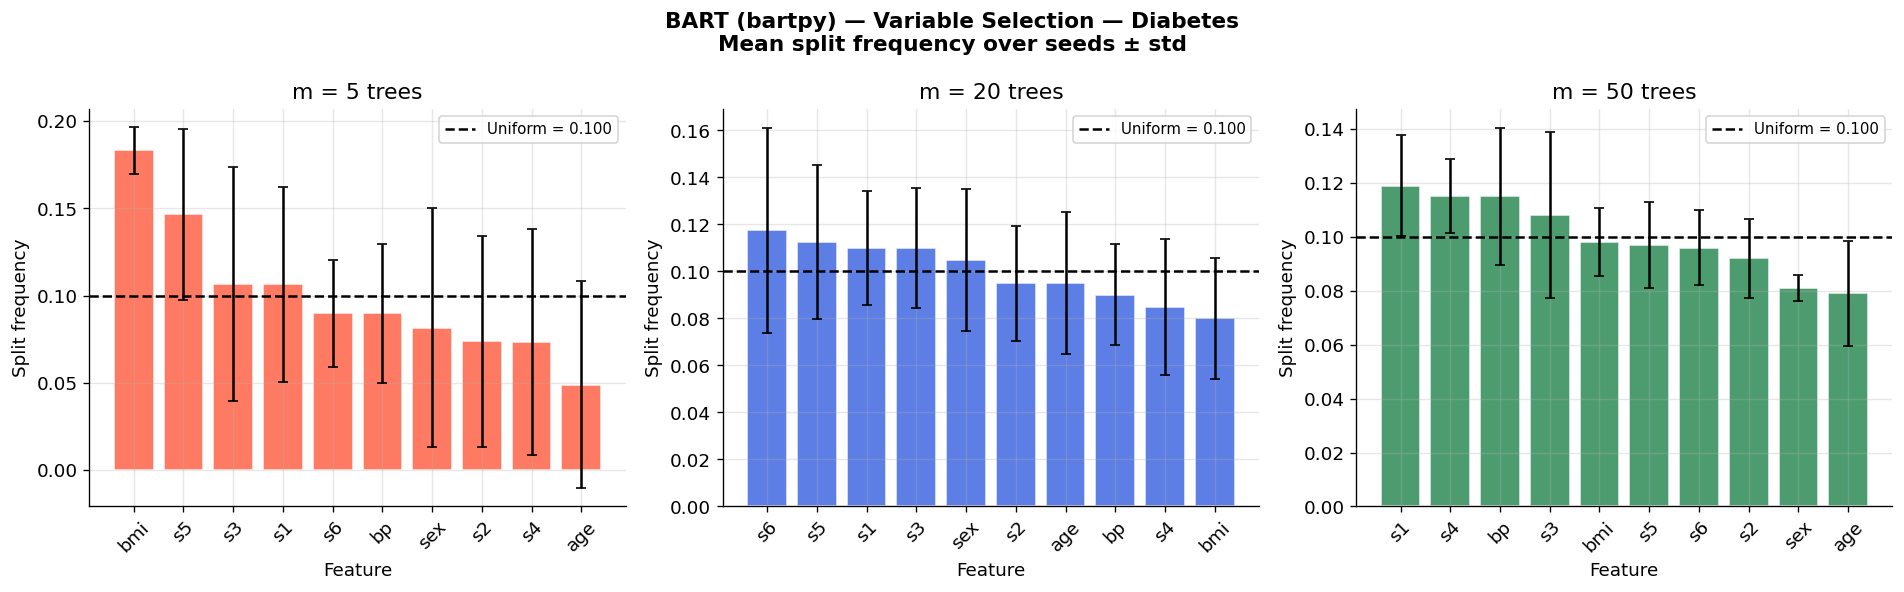

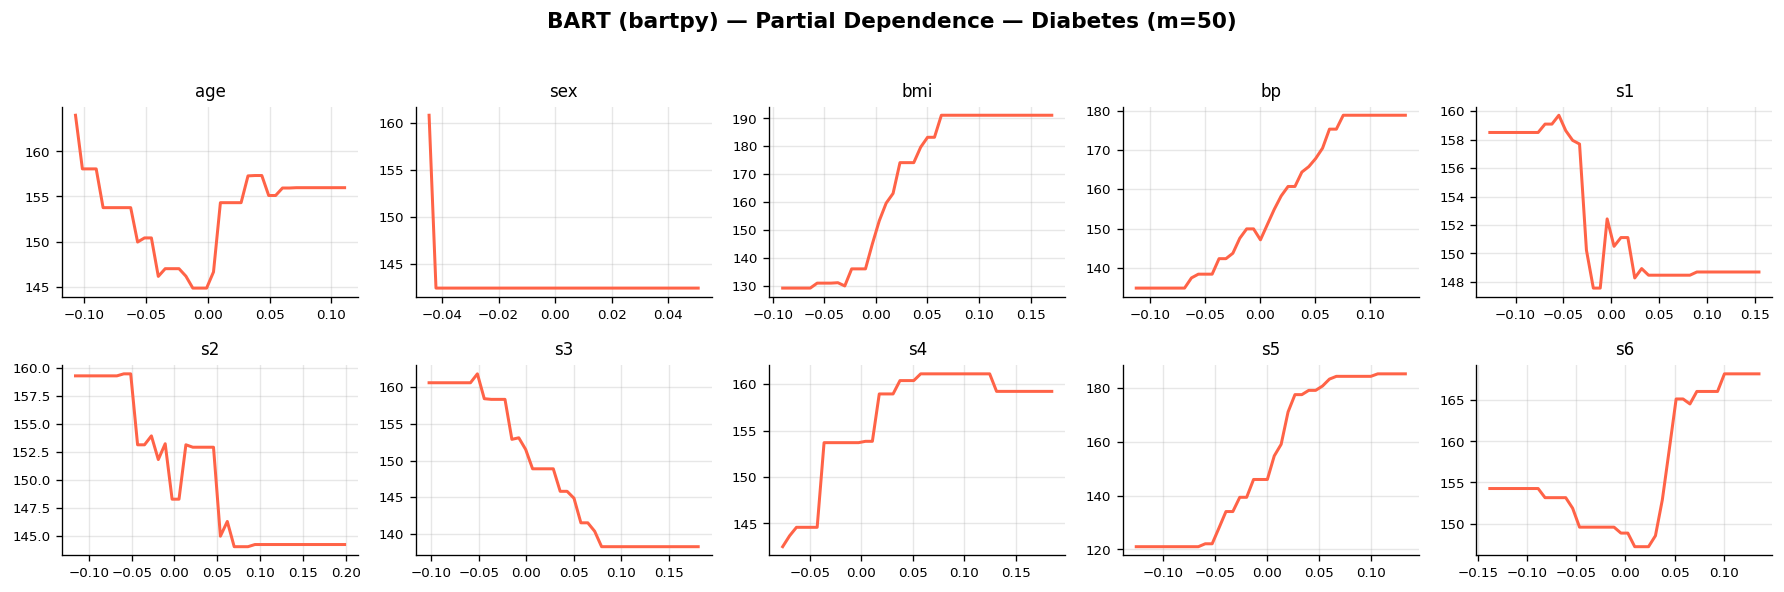

In [12]:
def bartpy_partial_dependence(model, X, feature_idx, grid_points=40):
    X = np.asarray(X)
    xj = X[:, feature_idx]

    grid = np.linspace(np.min(xj), np.max(xj), grid_points)
    pd_vals = []

    for val in grid:
        X_mod = X.copy()
        X_mod[:, feature_idx] = val
        preds = bartpy_predict(model, X_mod)
        pd_vals.append(np.mean(preds))

    return grid, np.asarray(pd_vals)


diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target
feat_names_diab = np.array(diabetes.feature_names)
p_diab = X_diab.shape[1]

print(f"Diabetes: {X_diab.shape[0]} samples, {p_diab} features: {list(feat_names_diab)}")

m_values = [5, 20, 50]
seeds = [0, 1, 2, 3, 4]

bart_results_all = {m: [] for m in m_values}
bart_models = {m: [] for m in m_values}

for m in m_values:
    print(f"\nFitting bartpy for m={m} over {len(seeds)} seeds...")
    for seed in seeds:
        set_seed(seed)
        model_m = bartpy_fit(X_diab, y_diab, n_trees=m, n_samples=200, n_burn=150)
        usage = np.asarray(bartpy_var_usage(model_m, p_diab))

        bart_results_all[m].append(usage)
        bart_models[m].append(model_m)

bart_results_all = {m: np.vstack(v) for m, v in bart_results_all.items()}
bart_mean = {m: bart_results_all[m].mean(axis=0) for m in m_values}
bart_std  = {m: bart_results_all[m].std(axis=0)  for m in m_values}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    "BART (bartpy) — Variable Selection — Diabetes\n"
    "Mean split frequency over seeds ± std",
    fontsize=13, fontweight='bold'
)

colors_m = {5: 'tomato', 20: 'royalblue', 50: 'seagreen'}
uniform = 1.0 / p_diab

for ax, m in zip(axes, m_values):
    mean_usage = bart_mean[m]
    std_usage = bart_std[m]

    sorted_idx = np.argsort(mean_usage)[::-1]
    names_sorted = feat_names_diab[sorted_idx]
    mean_sorted = mean_usage[sorted_idx]
    std_sorted = std_usage[sorted_idx]

    ax.bar(
        names_sorted,
        mean_sorted,
        yerr=std_sorted,
        capsize=3,
        color=colors_m[m],
        alpha=0.85,
        edgecolor='white',
        ecolor='black'
    )
    ax.axhline(
        uniform,
        color='black',
        linestyle='--',
        lw=1.5,
        label=f'Uniform = {uniform:.3f}'
    )
    ax.set_title(f'm = {m} trees')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Split frequency')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

m_dependence = 50
model_for_pdp = bart_models[m_dependence][0]  

n_features = len(feat_names_diab)
cols = 5
rows = int(np.ceil(n_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
axes = np.array(axes).ravel()

fig.suptitle(
    f"BART (bartpy) — Partial Dependence — Diabetes (m={m_dependence})\n",
    fontsize=13,
    fontweight='bold'
)

for j in range(n_features):
    grid, pd_vals = bartpy_partial_dependence(model_for_pdp, X_diab, j, grid_points=40)

    ax = axes[j]
    ax.plot(grid, pd_vals, color='tomato', lw=1.8)
    ax.set_title(feat_names_diab[j], fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

for k in range(n_features, len(axes)):
        fig.delaxes(axes[k])    

plt.tight_layout()
plt.show()    

---
## Feature Selection: Friedman's Benchmark

Friedman's function: $y = 10\sin(\pi x_1 x_2) + 20(x_3 - 0.5)^2 + 10x_4 + 5x_5 + \varepsilon$

Only $x_1, ..., x_5$ matter. We compare BART vs Lasso (linear) vs RandomForest vs GradientBoosting.

In [13]:
np.random.seed(42)
X_fried, y_fried = make_friedman1(n_samples=300, n_features=10, noise=1.0, random_state=42)
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_fried, y_fried, test_size=1/3, random_state=42)

print("Friedman benchmark: n=300, p=10 (5 relevant + 5 noise)")

results_fried = {}

lasso_f = LassoCV(cv=5, random_state=42).fit(X_tr_f, y_tr_f)
results_fried['Lasso'] = np.sqrt(mean_squared_error(y_te_f, lasso_f.predict(X_te_f)))

rf_f = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_tr_f, y_tr_f)
results_fried['Random Forest'] = np.sqrt(mean_squared_error(y_te_f, rf_f.predict(X_te_f)))

gb_f = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_f.fit(X_tr_f, y_tr_f)
results_fried['Gradient Boosting'] = np.sqrt(mean_squared_error(y_te_f, gb_f.predict(X_te_f)))

xgb_f = XGBRegressor(n_estimators=200, random_state=42)
xgb_f.fit(X_tr_f, y_tr_f)
results_fried['XGBoost'] = np.sqrt(mean_squared_error(y_te_f, xgb_f.predict(X_te_f)))

lgbm_f = LGBMRegressor(n_estimators=200, random_state=42)
lgbm_f.fit(X_tr_f, y_tr_f)
results_fried['LightGBM'] = np.sqrt(mean_squared_error(y_te_f, lgbm_f.predict(X_te_f)))

print("  Fitting bartpy Friedman...")
bart_f = bartpy_fit(X_tr_f, y_tr_f, n_trees=200, n_samples=1000, n_burn=1000)
results_fried['BART (bartpy)'] = np.sqrt(mean_squared_error(y_te_f, bartpy_predict(bart_f, X_te_f)))

# Variable usage from bartpy
bart_f_vi = bartpy_var_usage(bart_f, 10)

print("\n--- Test RMSE (Friedman) ---")
for method, rmse in sorted(results_fried.items(), key=lambda x: x[1]):
    print(f"  {method:<22}: {rmse:.3f}")


Friedman benchmark: n=300, p=10 (5 relevant + 5 noise)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 10
[LightGBM] [Info] Start training from score 14.626621
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

100%|██████████| 1000/1000 [00:14<00:00, 69.51it/s]


Starting sampling


100%|██████████| 1000/1000 [00:14<00:00, 69.36it/s]


Starting burn


...

Starting burn


100%|██████████| 1000/1000 [00:14<00:00, 69.82it/s]


Starting sampling


100%|██████████| 1000/1000 [00:13<00:00, 72.23it/s]



--- Test RMSE (Friedman) ---
  LightGBM              : 1.655
  BART (bartpy)         : 1.837
  Gradient Boosting     : 1.873
  Random Forest         : 2.222
  XGBoost               : 2.489
  Lasso                 : 2.545


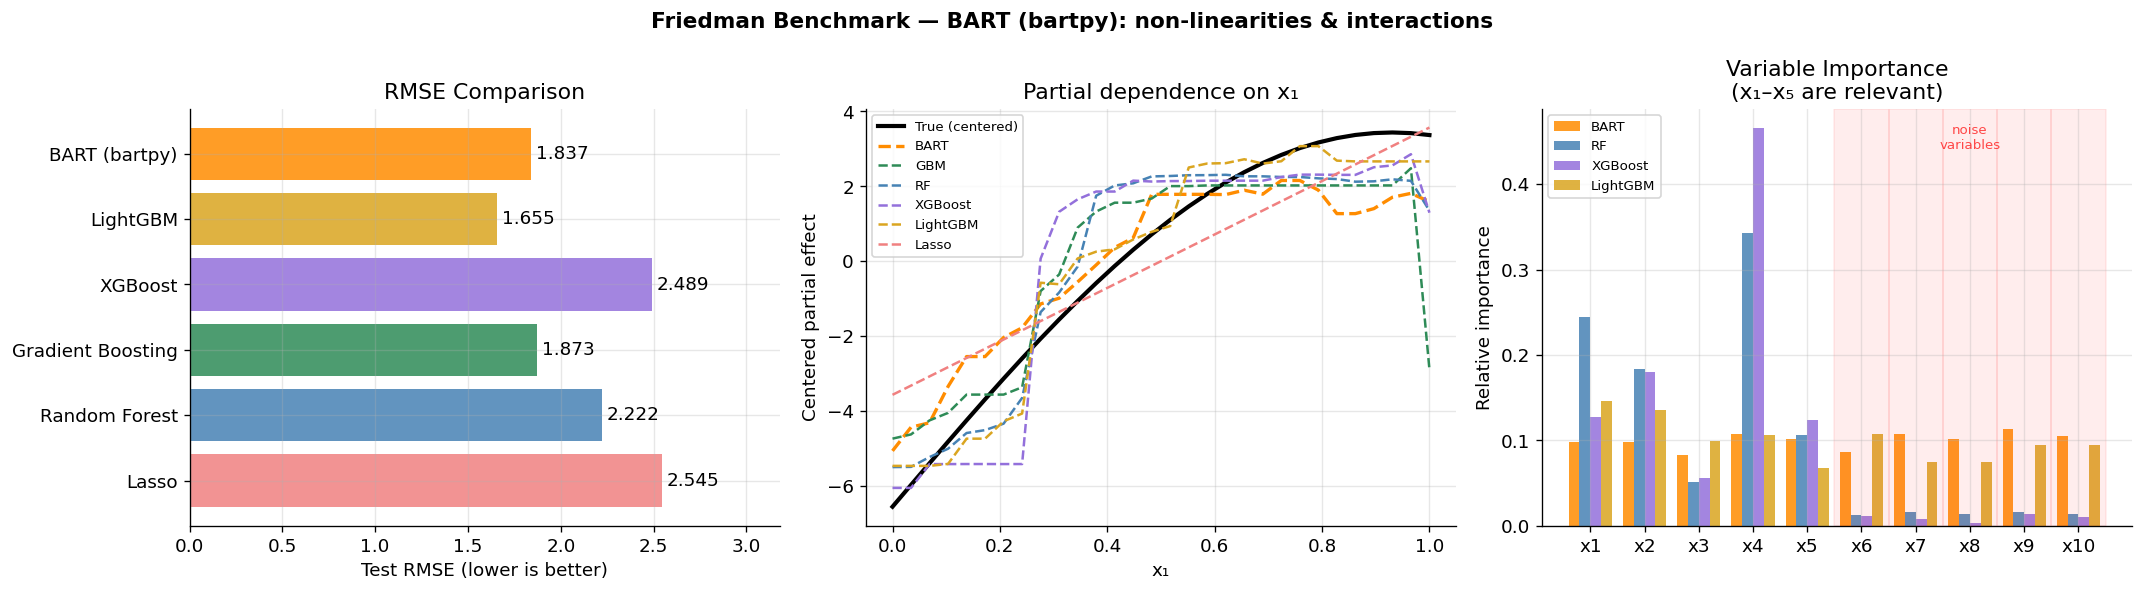

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Friedman Benchmark — BART (bartpy): non-linearities & interactions",
             fontsize=13, fontweight='bold')

color_map = {
    'Lasso': 'lightcoral',
    'Random Forest': 'steelblue',
    'Gradient Boosting': 'seagreen',
    'XGBoost': 'mediumpurple',
    'LightGBM': 'goldenrod',
    'BART (bartpy)': 'darkorange'
}

# RMSE
ax = axes[0]
methods = list(results_fried.keys())
rmses = [results_fried[m] for m in methods]
bars = ax.barh(methods, rmses, color=[color_map[m] for m in methods], alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Test RMSE (lower is better)')
ax.set_title('RMSE Comparison')
ax.set_xlim(0, max(rmses) * 1.25)

# Partial dependence on x1
ax = axes[1]
x1_vals = np.linspace(0, 1, 30)
X_pdp = np.tile(X_tr_f.mean(axis=0), (30, 1))
X_pdp[:, 0] = x1_vals

x2_mean = X_tr_f[:, 1].mean()
true_pdp = 10 * np.sin(np.pi * x1_vals * x2_mean)

bart_pdp  = bartpy_predict(bart_f, X_pdp)
gb_pdp    = gb_f.predict(X_pdp)
rf_pdp    = rf_f.predict(X_pdp)
lasso_pdp = lasso_f.predict(X_pdp)
xgb_pdp   = xgb_f.predict(X_pdp)
lgbm_pdp  = lgbm_f.predict(X_pdp)

ax.plot(x1_vals, true_pdp - true_pdp.mean(),  'k-', lw=2.5, label='True (centered)')
ax.plot(x1_vals, bart_pdp - bart_pdp.mean(), '--', color='darkorange', lw=2, label='BART')
ax.plot(x1_vals, gb_pdp - gb_pdp.mean(), '--', color='seagreen', lw=1.5, label='GBM')
ax.plot(x1_vals, rf_pdp - rf_pdp.mean(), '--', color='steelblue', lw=1.5, label='RF')
ax.plot(x1_vals, xgb_pdp - xgb_pdp.mean(), '--', color='mediumpurple', lw=1.5, label='XGBoost')
ax.plot(x1_vals, lgbm_pdp - lgbm_pdp.mean(), '--', color='goldenrod', lw=1.5, label='LightGBM')
ax.plot(x1_vals, lasso_pdp - lasso_pdp.mean(), '--', color='lightcoral', lw=1.5, label='Lasso')

ax.set_xlabel('x₁')
ax.set_ylabel('Centered partial effect')
ax.set_title('Partial dependence on x₁')
ax.legend(fontsize=8)

# Variable importance
ax = axes[2]
feat_labels = [f'x{i+1}' for i in range(10)]
x = np.arange(10)

rf_vi = rf_f.feature_importances_
xgb_vi = xgb_f.feature_importances_
lgbm_vi = lgbm_f.feature_importances_
bart_vi = np.array(bart_f_vi)

# normalize to make methods visually comparable
rf_vi = rf_vi / rf_vi.sum()
xgb_vi = xgb_vi / xgb_vi.sum()
lgbm_vi = lgbm_vi / lgbm_vi.sum()
bart_vi = bart_vi / bart_vi.sum()

w = 0.2

ax.bar(x - 1.5*w, bart_vi, w, label='BART', color='darkorange', alpha=0.85)
ax.bar(x - 0.5*w, rf_vi,   w, label='RF', color='steelblue', alpha=0.85)
ax.bar(x + 0.5*w, xgb_vi,  w, label='XGBoost', color='mediumpurple', alpha=0.85)
ax.bar(x + 1.5*w, lgbm_vi, w, label='LightGBM', color='goldenrod', alpha=0.85)

for i in range(5, 10):
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.07, color='red')

ax.text(
    7,
    max(bart_vi.max(), rf_vi.max(), xgb_vi.max(), lgbm_vi.max()) * 0.95,
    'noise\nvariables',
    ha='center',
    fontsize=8,
    color='red',
    alpha=0.7
)

ax.set_xticks(x)
ax.set_xticklabels(feat_labels)
ax.set_ylabel('Relative importance')
ax.set_title('Variable Importance\n(x₁–x₅ are relevant)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Starting batched PDP computation...
Train shape: (200, 10)
Number of features: 10

Computing PDP for x1 (1/10)...
    feature_idx=0 | grid_points=20 | n_reference=100
    X_big shape = (2000, 10)
    single batched predict_time = 22.424s
Finished x1 | elapsed=22.426s

Computing PDP for x2 (2/10)...
    feature_idx=1 | grid_points=20 | n_reference=100
    X_big shape = (2000, 10)
    single batched predict_time = 22.304s
Finished x2 | elapsed=22.304s

Computing PDP for x3 (3/10)...
    feature_idx=2 | grid_points=20 | n_reference=100
    X_big shape = (2000, 10)
    single batched predict_time = 22.410s
Finished x3 | elapsed=22.410s

Computing PDP for x4 (4/10)...
    feature_idx=3 | grid_points=20 | n_reference=100
    X_big shape = (2000, 10)
    single batched predict_time = 23.215s
Finished x4 | elapsed=23.215s

Computing PDP for x5 (5/10)...
    feature_idx=4 | grid_points=20 | n_reference=100
    X_big shape = (2000, 10)
    single batched predict_time = 21.956s
Finished x5 | elap

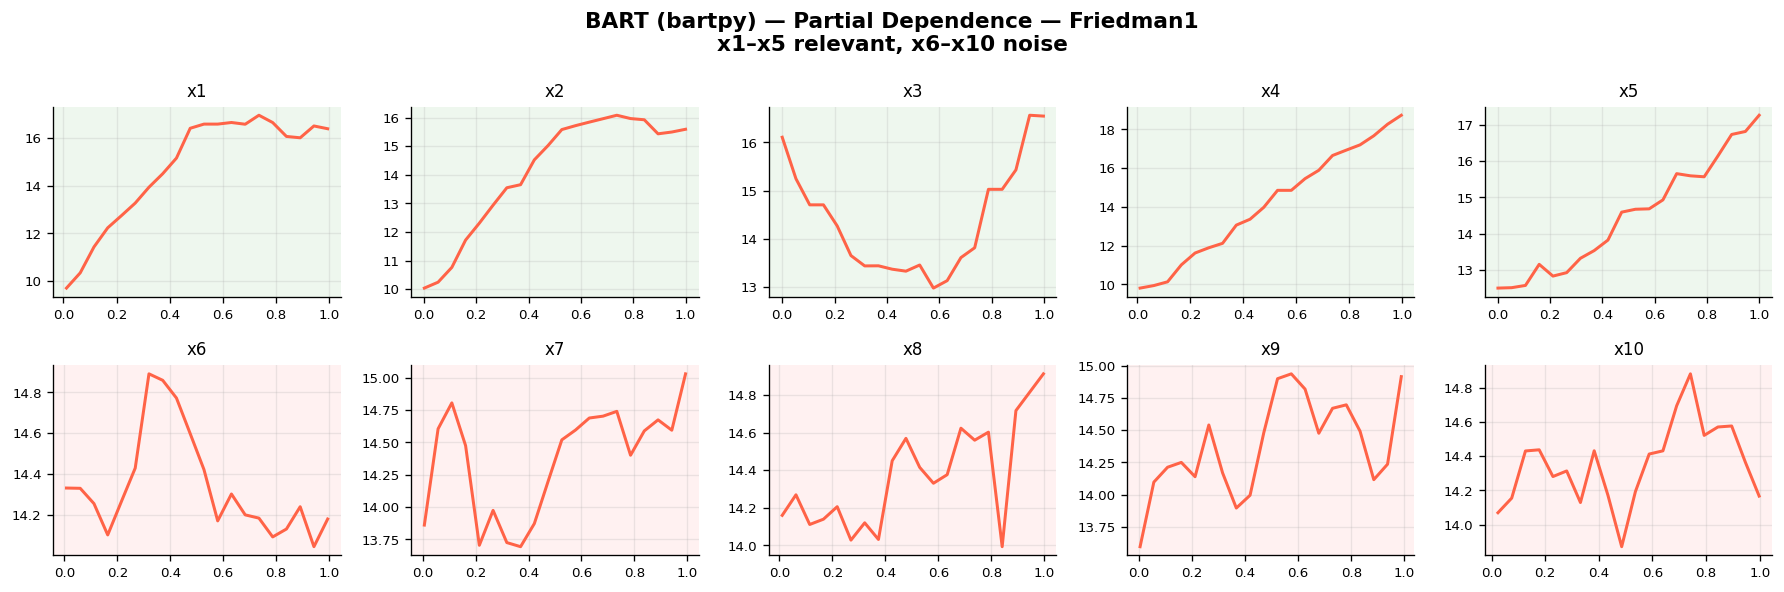

In [15]:
def bartpy_partial_dependence_batched(
    model,
    X,
    feature_idx,
    grid_points=10,
    n_reference=30,
    seed=42,
    verbose=True
):
    X = np.asarray(X)
    rng = np.random.default_rng(seed)

    if len(X) > n_reference:
        ref_idx = rng.choice(len(X), size=n_reference, replace=False)
        X_ref = X[ref_idx].copy()
    else:
        X_ref = X.copy()

    xj = X[:, feature_idx]
    grid = np.linspace(np.min(xj), np.max(xj), grid_points)

    if verbose:
        print(
            f"    feature_idx={feature_idx} | "
            f"grid_points={grid_points} | "
            f"n_reference={len(X_ref)}"
        )

    # Build one big batch: shape = (grid_points * n_reference, n_features)
    X_blocks = []
    for val in grid:
        X_mod = X_ref.copy()
        X_mod[:, feature_idx] = val
        X_blocks.append(X_mod)

    X_big = np.vstack(X_blocks)

    if verbose:
        print(f"    X_big shape = {X_big.shape}")

    t0 = time.perf_counter()
    preds_big = np.asarray(bartpy_predict(model, X_big))
    t1 = time.perf_counter()

    if verbose:
        print(f"    single batched predict_time = {t1 - t0:.3f}s")

    # reshape to (grid_points, n_reference)
    preds_big = preds_big.reshape(grid_points, len(X_ref))
    pd_vals = preds_big.mean(axis=1)

    return grid, pd_vals

feature_names_fried = [f"x{i}" for i in range(1, 11)]

n_features = X_tr_f.shape[1]
cols = 5
rows = int(np.ceil(n_features / cols))

print("Starting batched PDP computation...")
print(f"Train shape: {X_tr_f.shape}")
print(f"Number of features: {n_features}")

fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.5 * rows))
axes = np.asarray(axes).ravel()

fig.suptitle(
    "BART (bartpy) — Partial Dependence — Friedman1\n"
    "x1–x5 relevant, x6–x10 noise",
    fontsize=13,
    fontweight="bold"
)

t_total_start = time.perf_counter()

for j in range(n_features):
    print(f"\nComputing PDP for {feature_names_fried[j]} ({j+1}/{n_features})...")

    t_var_start = time.perf_counter()

    grid, pd_vals = bartpy_partial_dependence_batched(
        bart_f,
        X_tr_f,
        feature_idx=j,
        grid_points=20,
        n_reference=100,
        seed=42,
        verbose=True
    )

    t_var_end = time.perf_counter()
    print(f"Finished {feature_names_fried[j]} | elapsed={t_var_end - t_var_start:.3f}s")

    ax = axes[j]
    ax.plot(grid, pd_vals, color="tomato", lw=1.8)
    ax.set_title(feature_names_fried[j], fontsize=10)

    if j < 5:
        ax.set_facecolor("#eef7ee")
    else:
        ax.set_facecolor("#fff1f1")

    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=8)

for k in range(n_features, len(axes)):
    fig.delaxes(axes[k])

t_total_end = time.perf_counter()
print(f"\nAll PDPs finished in {t_total_end - t_total_start:.3f}s")

plt.tight_layout()
plt.show()

---
## High Dimensional Data: Performance

The paper admits that BART-default breaks down in high-dimensional settings. The default Sigma prior needs adjustment when p >> n.

In [16]:
np.random.seed(42)
n_obs    = 200
p_values = [10, 100,500,1000,2000]

def friedman_y(X):
    return (10 * np.sin(np.pi * X[:,0] * X[:,1]) +
            20 * (X[:,2] - 0.5)**2 +
            10 * X[:,3] + 5 * X[:,4])

rmse_by_p = {m: [] for m in ['BART (bartpy)', 'Random Forest', 'Gradient Boosting', 'Lasso','XGBoost','LightGBM']}

for p in p_values:
    X_hd = np.random.uniform(0, 1, (n_obs, p))
    y_hd = friedman_y(X_hd) + np.random.normal(0, 1, n_obs)
    X_tr, X_te, y_tr, y_te = train_test_split(X_hd, y_hd, test_size=0.33, random_state=42)

    b = bartpy_fit(X_tr, y_tr, n_trees=50, n_samples=100, n_burn=500)
    rmse_by_p['BART (bartpy)'].append(np.sqrt(mean_squared_error(y_te, bartpy_predict(b, X_te))))

    rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_tr, y_tr)
    rmse_by_p['Random Forest'].append(np.sqrt(mean_squared_error(y_te, rf.predict(X_te))))

    gb = GradientBoostingRegressor(n_estimators=200, random_state=42).fit(X_tr, y_tr)
    rmse_by_p['Gradient Boosting'].append(np.sqrt(mean_squared_error(y_te, gb.predict(X_te))))

    # XGBoost
    xgb = XGBRegressor(n_estimator=200, random_state=42, verbosity=0).fit(X_tr, y_tr)
    rmse_by_p['XGBoost'].append(
        np.sqrt(mean_squared_error(y_te, xgb.predict(X_te)))
    )

    # LightGBM
    lgbm = LGBMRegressor(n_estimator=200,random_state=42).fit(X_tr, y_tr)
    rmse_by_p['LightGBM'].append(
        np.sqrt(mean_squared_error(y_te, lgbm.predict(X_te)))
    )

    lasso = LassoCV(cv=5, random_state=42).fit(X_tr, y_tr)
    rmse_by_p['Lasso'].append(np.sqrt(mean_squared_error(y_te, lasso.predict(X_te))))

    print(f"p={p:3d}: "
          + " ".join(f"{m.split()[0]}={rmse_by_p[m][-1]:.2f}" for m in rmse_by_p))


Starting burn


100%|██████████| 500/500 [00:01<00:00, 290.76it/s]


Starting sampling


100%|██████████| 100/100 [00:00<00:00, 288.54it/s]


Starting burn


...

Starting burn


100%|██████████| 500/500 [00:27<00:00, 17.92it/s]


Starting sampling


100%|██████████| 100/100 [00:05<00:00, 18.40it/s]


[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 92000
[LightGBM] [Info] Number of data points in the train set: 134, number of used features: 2000
[LightGBM] [Info] Start training from score 14.355391
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

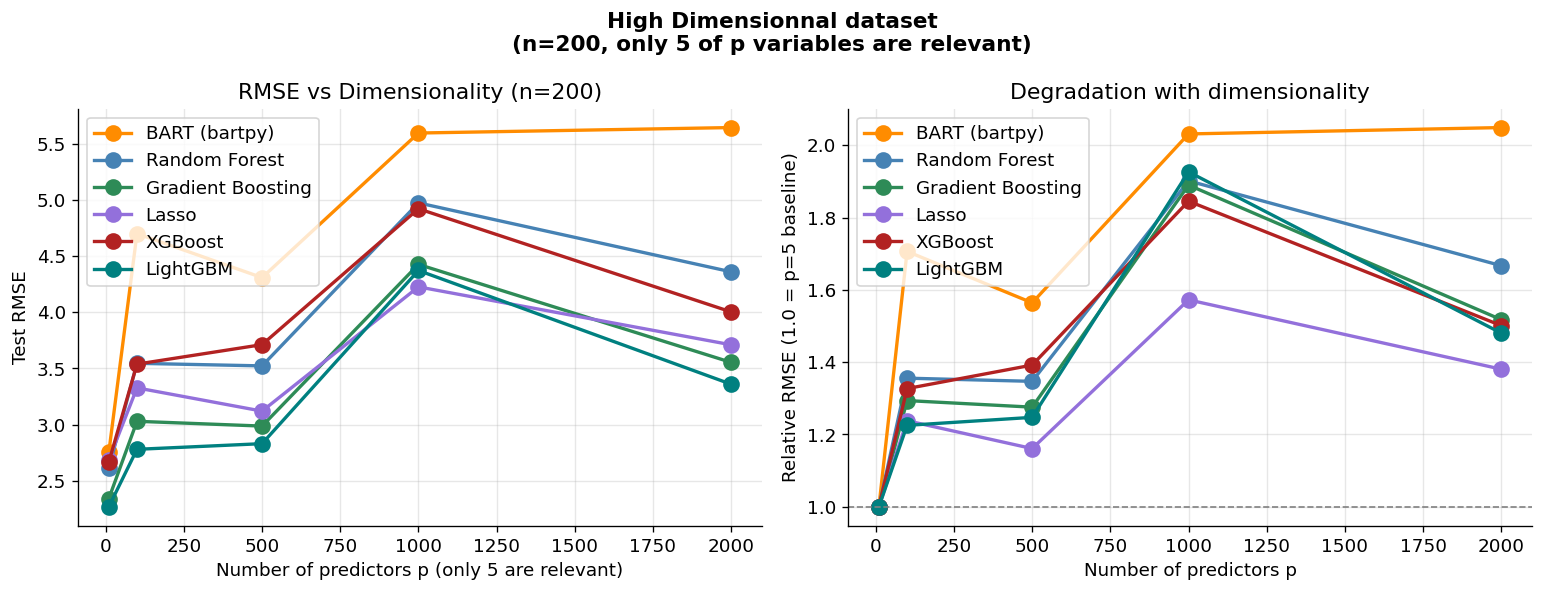

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("High Dimensionnal dataset\n"
             f"(n={n_obs}, only 5 of p variables are relevant)",
             fontsize=13, fontweight='bold')

colors_hd = {
    'BART (bartpy)': 'darkorange',
    'Random Forest': 'steelblue',
    'Gradient Boosting': 'seagreen',
    'XGBoost': 'firebrick',
    'LightGBM': 'teal',
    'Lasso': 'mediumpurple'
}

ax = axes[0]
for method, rmses in rmse_by_p.items():
    ax.plot(p_values, rmses, 'o-', label=method, lw=2, ms=9, color=colors_hd[method])
ax.set_xlabel('Number of predictors p (only 5 are relevant)')
ax.set_ylabel('Test RMSE')
ax.set_title(f'RMSE vs Dimensionality (n={n_obs})')
ax.legend()

ax = axes[1]
baselines = {m: rmse_by_p[m][0] for m in rmse_by_p}
for method, rmses in rmse_by_p.items():
    rel = [r / baselines[method] for r in rmses]
    ax.plot(p_values, rel, 'o-', label=method, lw=2, ms=9, color=colors_hd[method])
ax.axhline(1.0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Number of predictors p')
ax.set_ylabel('Relative RMSE (1.0 = p=5 baseline)')
ax.set_title('Degradation with dimensionality')
ax.legend()

plt.tight_layout()
plt.show()


---
## High Dimensional Data: Performance: MCMC Convergence

Unlike point-estimate methods, BART requires **diagnosing MCMC convergence**, which adds complexity.

In [18]:
np.random.seed(42)
X_conv, y_conv = make_friedman1(n_samples=200, n_features=100, noise=1.0)

results_conv = {}
for burn in [100, 1000, 10000]:
    print(f"  Fitting bartpy burn={burn}...")
    b = bartpy_fit(X_conv, y_conv, n_trees=50, n_samples=1000, n_burn=burn)
    sigma_tr = bartpy_sigma_trace(b)
    results_conv[f'burn={burn}'] = {
        'sigma_trace': sigma_tr,
        'post_mean':   b.predict(),
    }
    print(f"  burn={burn}: Sigma mean={sigma_tr.mean():.4f}, Sigma std={sigma_tr.std():.4f}")


  Fitting bartpy burn=100...
Starting burn


100%|██████████| 100/100 [00:00<00:00, 182.58it/s]


Starting sampling


100%|██████████| 1000/1000 [00:05<00:00, 183.27it/s]


Starting burn


...

Starting burn


100%|██████████| 10000/10000 [00:51<00:00, 194.79it/s]


Starting sampling


100%|██████████| 1000/1000 [00:05<00:00, 194.23it/s]

  burn=10000: Sigma mean=0.1228, Sigma std=0.0100


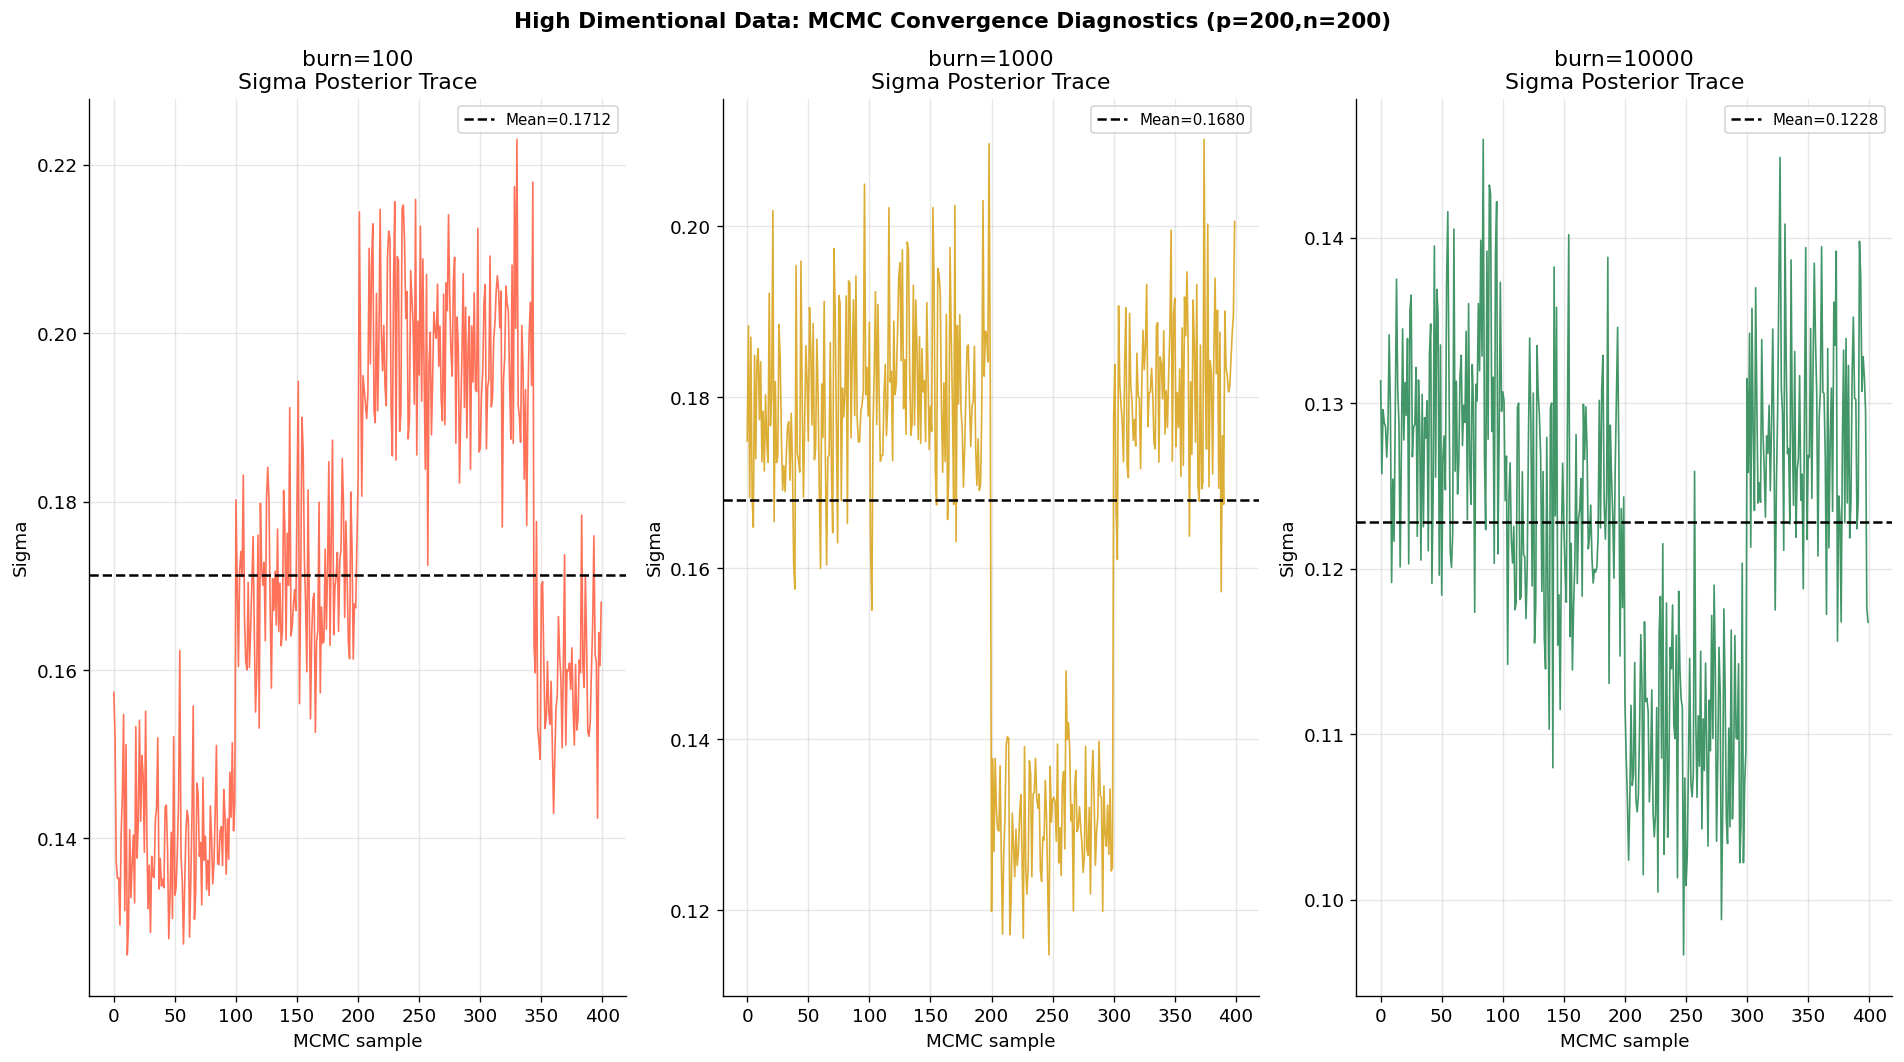

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 9))
fig.suptitle("High Dimentional Data: MCMC Convergence Diagnostics (p=200,n=200)",
             fontsize=13, fontweight='bold')

colors_burn = {'burn=100': 'tomato', 'burn=1000': 'goldenrod', 'burn=10000': 'seagreen'}

for col, (label, res) in enumerate(results_conv.items()):
    trace = res['sigma_trace']

    ax = axes[col]
    ax.plot(trace, lw=1, alpha=0.9, color=colors_burn[label])
    ax.axhline(trace.mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean={trace.mean():.4f}')
    ax.set_title(f'{label}\nSigma Posterior Trace')
    ax.set_xlabel('MCMC sample')
    ax.set_ylabel('Sigma')
    ax.legend(fontsize=9)


plt.tight_layout()
plt.show()
